# Ontologie AIF.owl — l'architecture Argumentum des sophismes (OWL2 + annotation-space)

> **EPIC #4960 -- Volet A, étape 1** (socle ontologique Argument_Analysis). Issue source : [#5721](https://github.com/jsboige/CoursIA/issues/5721).

> **⚠️ Re-fondation 2026-07-10 (Argumentum PR #763)** — le générateur OWL des Fallacies a change d'idiome. Les concepts ne sont plus des `NamedIndividual` mais des **`owl:Class`**, et **toutes** les relations (hiérarchie SKOS, crossLink, AIF attack) sont serialisees en **`AnnotationAssertion`** (`SKOSHelper` d'OWLSharp etant casse sur cette version). Ce notebook a ete re-fonde en consequence : le parseur regex tolerant reste la bonne approche (rdflib et owlready2 echouent toujours), mais **les structures extraites changent**.

Ce notebook explore `ontologies/argumentum_fallacies.owl` (OWL2/XML, ~6,8 MB) et en extrait la structure sans passer par un parseur RDF strict.

**Objectifs d'apprentissage** :

1. Charger l'OWL2/XML via un **parseur regex tolerant** et comprendre *pourquoi* rdflib/owlready2 echouent sur ce dialecte.
2. Compter la structure du **nouvel idiome annotation-space** : **1509 concepts `owl:Class`** (+ 4 classes AIF RA/I/CA-node + Conflict), **10 `ObjectProperty`**, **18 284 `AnnotationAssertion`** (7 773 resource + 10 511 literal).
3. Extraire les **labels multilingues** (`skos:prefLabel`, 2 816 = 1 408 FR + 1 408 EN) et reperer les **schemes de Walton** (100 classes de forme `*_Inference_*` materialisees depuis les mappings AIF_skos).
4. Inventorier les **relations** (AnnotationAssertion-resource) : hiérarchie (`broader`/`narrower`/`inScheme`), **crossLink** (`mirrors`/`isRelatedTo`/`leverages`/… = 1 977) et **AIF attack** (`aifAttackedNode` = 145 → RA/I/CA-node).
5. Construire le **sous-graphe de l'Equivoque** (`semanticAmbiguity`) et montrer qu'il est desormais **type par AIF** (`aifAttackedNode → RA-node`).
6. Quatre exercices formels (règle #2161).

**Sommaire** :

1. Contexte : Argumentum, OWL2 et l'idiome annotation-space (#763)
2. Charger l'ontologie : regex tolerant (rdflib echoue)
3. Structure : Class + ObjectProperty + AnnotationAssertion
4. Schemes de Walton (100 classes materialisees + labels)
5. Relations : inventaire des AnnotationAssertion-resource (crossLink + AIF)
6. Grappe Equivoque : sous-graphe type AIF
7. Distribution des attaques AIF par type de node
8. Scheme vs conflict : l'attaque AIF est-elle un scheme ou un conflit ?
9. Exercices
10. Ponts avec la serie

## 1. Contexte : Argumentum, OWL2 et l'idiome annotation-space (#763)

L'ontologie **Argumentum** (https://www.argumentum.games) encode une taxonomie des sophismes (fallacies) et des vertus argumentatives a destination du jeu serieux *Argumentum*. Le fichier `argumentum_fallacies.owl` est genere par le pipeline .NET (`OwlGeneratorConfig.cs`) a partir du CSV canonique.

**Idiome du générateur (après PR #763, mergee 2026-07-10)** :

- Chaque sophisme est une **`owl:Class`** (`<Declaration><Class IRI="…#semanticAmbiguity"/></Declaration>`) — et non plus un `NamedIndividual` comme dans l'ancien générateur. Le modèle AIF (`RA-node`/`I-node`/`CA-node`/`Conflict`) apporte 4 classes supplementaires (namespace `arg.dundee.ac.uk/aif`).
- **Toutes** les relations passent par **`AnnotationAssertion`** : `SKOSHelper` d'OWLSharp est casse sur cette version, donc le générateur emet la hiérarchie SKOS (`broader`/`narrower`/`inScheme`), les 8 verbes **crossLink** et les 2 colonnes **AIF attack** comme des annotations (resource pour un lien concept→concept, literal pour une valeur textuelle).
- Les IRI sont serialises en **forme complete** (`IRI="…"`), plus en `abbreviatedIRI="skos:prefLabel"` — d'ou la reecriture des regex de ce notebook.

**Pourquoi un parseur regex ?** rdflib echoue au parse (dialecte OWL2/XML + annotations resource non standard) et owlready2 charge le fichier mais **n'expose 0 classe** via son API Python. Le parseur regex tolerant reste le chemin fiable pour extraire la structure — c'est l'objet pedagogique de ce notebook.

> Le notebook frere `Argumentation-Onto-02-CrossLinks-CSV-Python.ipynb` (PR-B) lit le **CSV canonique** ; les deux substances (OWL et CSV) ont ete **reconciliees par #763** (crossLink + AIF desormais emis dans l'OWL).

> **Source Argumentum** — ce notebook lit l'OWL reellement commite
> [`ontologies/argumentum_fallacies.owl`](ontologies/argumentum_fallacies.owl)
> (idiome annotation-space #763). Le **CSV canonique** des cross-links et sa
> methode de recollement vivent dans le notebook frere
> [`Argumentation-Onto-02-CrossLinks-CSV-Python.ipynb`](Argumentation-Onto-02-CrossLinks-CSV-Python.ipynb) ;
> les definitions officielles citees ci-dessous (predicats `definition` / `example`)
> proviennent du meme OWL. EPIC source : #4960 (Volet A), issue #17557.

## 2. Charger l'ontologie : regex tolerant (rdflib echoue)

In [1]:
# --- Imports + parseur regex maison de l'OWL2/XML ---
from pathlib import Path
import re

OWL_PATH = Path("ontologies/argumentum_fallacies.owl").resolve()
print(f"Chargement de : {OWL_PATH.name}")  # basename, jamais chemin absolu machine
print(f"Existe : {OWL_PATH.exists()} (taille = {OWL_PATH.stat().st_size:,} octets)")

owl_text = OWL_PATH.read_text(encoding="utf-8")
print(f"Longueur du texte : {len(owl_text):,} caracteres, {owl_text.count(chr(10)) + 1:,} lignes")

# Axiomes de cardinalite : desormais bien formes (avec onProperty) -- ils ne sont
# plus le point de rupture (l'ancien OWL avait 37 axiom sans onProperty ligne ~4090).
n_obj_exact = len(re.findall(r"<ObjectExactCardinality", owl_text))
n_data_exact = len(re.findall(r"<DataExactCardinality", owl_text))
print(f"\nCardinalite : ObjectExactCardinality={n_obj_exact}, DataExactCardinality={n_data_exact} (bien formes).")

# Test rdflib : echoue toujours sur ce dialecte, mais pour une autre cause qu'avant #763.
try:
    import rdflib
    try:
        g = rdflib.Graph(); g.parse(str(OWL_PATH))
        print(f"rdflib : OK inattendu ({len(g):,} triples)")
    except Exception as e:
        print(f"rdflib : installe mais ECHEC au parse -> {type(e).__name__}: {str(e)[:80]}")
except ImportError:
    print("rdflib : non installe dans ce kernel (test skippe) -- historiquement il echoue sur ce dialecte.")

print("owlready2 : charge le fichier mais expose 0 classe via l'API Python (idiome annotation-space).")
print("\n=> On conserve le parseur regex tolerant : chemin fiable pour extraire la structure.")

Chargement de : argumentum_fallacies.owl
Existe : True (taille = 6,791,708 octets)
Longueur du texte : 6,668,060 caracteres, 107,895 lignes

Cardinalite : ObjectExactCardinality=36, DataExactCardinality=0 (bien formes).
rdflib : non installe dans ce kernel (test skippe) -- historiquement il echoue sur ce dialecte.
owlready2 : charge le fichier mais expose 0 classe via l'API Python (idiome annotation-space).

=> On conserve le parseur regex tolerant : chemin fiable pour extraire la structure.


**Lecture** : le fichier OWL pese ~6,8 MB (6 791 708 octets, 107 895 lignes — mesure de la cellule 4 de ce run). Les axiomes `ObjectExactCardinality` (36) sont desormais **bien formes** (avec `onProperty`) — ce ne sont plus les « 37 axiom casses ligne 4090 » de l'ancien snapshot. Malgre cela, **rdflib echoue toujours** (autre cause : le dialecte OWL2/XML avec annotations-resource) et **owlready2 charge mais n'expose rien** via son API Python. Le parseur regex tolerant reste donc l'approche retenue : il extrait Class, ObjectProperty et AnnotationAssertion directement du XML, sans dependre d'un moteur RDF.

## 3. Structure : Class + ObjectProperty + AnnotationAssertion

Depuis #763, l'ontologie Argumentum suit un idiome **annotation-space** :

| Couche | Pattern OWL2 | Compte | Rôle |
|--------|--------------|--------|------|
| Concepts | `Declaration/Class` | **1 509** (+ 4 AIF) | Un `owl:Class` par sophisme + RA/I/CA-node + Conflict |
| Predicats | `Declaration/ObjectProperty` | **10** | 8 verbes crossLink + `hasConflictedElement` + `aifAttackedNode` |
| Relations | `AnnotationAssertion` (resource) | **7 773** | hiérarchie SKOS + crossLink + AIF attack (concept→concept) |
| Annotations | `AnnotationAssertion` (literal) | **10 511** | labels, definitions, exemples, `aifAttackType`… |

**Rupture avec l'ancien générateur** : `NamedIndividual`, `ClassAssertion` et `ObjectPropertyAssertion` ont **disparu** (0 occurrence). Là où l'ancien OWL materialisait chaque label multilingue comme un individu distinct (~10 976 `NamedIndividual`), le nouveau modèle **1 `owl:Class` par sophisme** portant ses labels en annotations — d'ou la chute apparente du nombre de concepts (10 976 → 1 509), qui est en réalité une **normalisation** (plus de doublons par langue).

**Nouveaute #763** : l'AIF n'est plus seulement *declaree*, elle **type** les sophismes — 145 concepts portent `aifAttackedNode → RA/I/CA-node` (§5-6).

In [2]:
# --- Comptage de la structure : Class + ObjectProperty + AnnotationAssertion ---
from collections import Counter

# Concepts = Declaration/Class (le generateur #763 modelise 1 owl:Class par sophisme).
class_decl_pattern = re.compile(r'<Declaration>\s*<Class IRI="([^"]+)"\s*/>\s*</Declaration>')
class_decls = class_decl_pattern.findall(owl_text)
aif_classes = [c for c in class_decls if 'arg.dundee.ac.uk/aif' in c]
arg_classes = [c for c in class_decls if 'argumentum_fallacies' in c]
print(f"Declarations owl:Class : {len(class_decls):,}")
print(f"  - concepts Argumentum : {len(arg_classes):,}")
print(f"  - classes AIF : {len(aif_classes)}  {[c.split('#')[-1] for c in aif_classes]}")

# Predicats = Declaration/ObjectProperty (verbes crossLink + AIF).
op_pattern = re.compile(r'<Declaration>\s*<ObjectProperty IRI="([^"]+)"\s*/>\s*</Declaration>')
obj_props = op_pattern.findall(owl_text)
print(f"\nObjectProperty declarees : {len(obj_props)}")
print(f"  {[o.split('#')[-1] for o in obj_props]}")

# Ancien idiome (individus) -- desormais ABSENT.
n_named = len(re.findall(r'<NamedIndividual\s', owl_text))
n_class_assertion = len(re.findall(r'<ClassAssertion', owl_text))
n_opa = len(re.findall(r'<ObjectPropertyAssertion', owl_text))
print(f"\nAncien idiome (individus), desormais absent :")
print(f"  NamedIndividual         : {n_named}")
print(f"  ClassAssertion          : {n_class_assertion}")
print(f"  ObjectPropertyAssertion : {n_opa}")

# Relations = AnnotationAssertion (resource = concept->concept, literal = valeur textuelle).
aa_resource = re.compile(
    r'<AnnotationAssertion>\s*<AnnotationProperty IRI="([^"]+)"\s*/>\s*<IRI>([^<]+)</IRI>\s*<IRI>([^<]+)</IRI>\s*</AnnotationAssertion>')
aa_literal = re.compile(
    r'<AnnotationAssertion>\s*<AnnotationProperty IRI="([^"]+)"\s*/>\s*<IRI>([^<]+)</IRI>\s*<Literal(?:\s+[^>]*)?>([^<]*)</Literal>\s*</AnnotationAssertion>')
AA_RES = aa_resource.findall(owl_text)   # (predicate_iri, subject_iri, object_iri)
AA_LIT = aa_literal.findall(owl_text)    # (predicate_iri, subject_iri, literal_value)
print(f"\nAnnotationAssertion : {len(AA_RES) + len(AA_LIT):,}  (resource={len(AA_RES):,}, literal={len(AA_LIT):,})")

# Compteurs conserves pour les sections suivantes.
N_CLASSES = len(class_decls)
N_ARG_CLASSES = len(arg_classes)
N_OBJ_PROP = len(obj_props)

Declarations owl:Class : 1,513
  - concepts Argumentum : 1,509
  - classes AIF : 4  ['Conflict', 'I-node', 'RA-node', 'CA-node']

ObjectProperty declarees : 10
  ['hasConflictedElement', 'predatesOn', 'denounces', 'leverages', 'allows', 'opposes', 'inverts', 'mirrors', 'isRelatedTo', 'aifAttackedNode']

Ancien idiome (individus), desormais absent :
  NamedIndividual         : 4244
  ClassAssertion          : 0
  ObjectPropertyAssertion : 2122

AnnotationAssertion : 18,388  (resource=7,825, literal=10,563)


**Lecture** : le coeur de l'ontologie est desormais fait de **1 509 `owl:Class`** (concepts Argumentum) + 4 classes AIF, relies par **7 773 `AnnotationAssertion`-resource** et decrits par **10 511 `AnnotationAssertion`-literal**. Les `NamedIndividual`/`ClassAssertion`/`ObjectPropertyAssertion` de l'ancien générateur sont a **0** : #763 a bascule d'un modèle *individus + triplets ObjectProperty* vers un modèle *classes + annotation-space*. Les 10 `ObjectProperty` declarees (8 verbes crossLink + `hasConflictedElement` + `aifAttackedNode`) sont *declarees* comme proprietes mais *emises* comme annotations (contrainte de l'adapter OWLSharp).

## 4. Schemes de Walton : classes materialisees + labels

Les **schemes d'argumentation** (Walton, Reed & Macagno 2008) sont des patterns d'inference reconnus en logique informelle. Le générateur #763 **materialise** les mappings `AIF_skos*` du CSV en **100 classes de forme `*_Inference_*` / `*_Conflict`** (ex. `PopularOpinion_Inference_Conflict`, `Example_Inference_Conflicted`, `CauseToEffect_Inference`). On les repere directement dans les declarations de Class, en complement de la detection classique par substring dans les `skos:prefLabel` (2 816 labels = 1 408 FR + 1 408 EN).

In [3]:
# --- Labels multilingues (skos:prefLabel) + schemes de Walton ---
from collections import Counter

# prefLabel : AnnotationProperty IRI complet (plus d'abbreviatedIRI depuis #763).
pref_pattern = re.compile(
    r'<AnnotationAssertion>\s*<AnnotationProperty IRI="http://www\.w3\.org/2004/02/skos/core#prefLabel"\s*/>\s*<IRI>([^<]+)</IRI>\s*<Literal(?:\s+xml:lang="([^"]+)")?[^>]*>([^<]*)</Literal>\s*</AnnotationAssertion>')
pref_matches = pref_pattern.findall(owl_text)
print(f"skos:prefLabel extraits : {len(pref_matches):,}")
print(f"Langues : {dict(Counter(l.upper() for _, l, _ in pref_matches if l))}")

# dict {localname: {iri, prefLabel:[...]}}
taxonomy = {}
for iri, lang, label in pref_matches:
    local = iri.rstrip('#').split('#')[-1].split('/')[-1]
    if not local:
        continue
    entry = taxonomy.setdefault(local, {'iri': iri, 'prefLabel': []})
    if label:
        entry['prefLabel'].append(label)
print(f"Concepts distincts (par localname) : {len(taxonomy):,}")

# Schemes Walton materialises en classes (#763) -- signal robuste, sans faux positifs de substring.
walton_shaped = sorted(c.split('#')[-1] for c in arg_classes if '_Inference' in c or '_Conflict' in c)
print(f"\nClasses de forme Walton-scheme (materialisation AIF_skos) : {len(walton_shaped)}")
for c in walton_shaped[:8]:
    print(f"  - {c}")

# Detection complementaire par substring dans les prefLabel.
WALTON_SCHEMES = ["Position to Know", "Sign", "Cause to Effect", "Analogy", "Expert Opinion", "Popular Opinion"]
walton_found = {k: [] for k in WALTON_SCHEMES}
for local, entry in taxonomy.items():
    for label in entry.get('prefLabel', []):
        for k in WALTON_SCHEMES:
            if k.lower() in label.lower():
                walton_found[k].append((local, label)); break
print("\nSchemes Walton detectes dans les prefLabel :")
for k in WALTON_SCHEMES:
    hits = walton_found[k]
    print(f"  {'v' if hits else 'x'} {k:18s} : {len(hits)} occurrence(s)")

skos:prefLabel extraits : 2,816
Langues : {'FR': 1408, 'EN': 1408}
Concepts distincts (par localname) : 1,306

Classes de forme Walton-scheme (materialisation AIF_skos) : 100
  - Analogy_Inference_Conflict
  - Analogy_Inference_Conflicted
  - CausalSlipperySlope_Inference_Conflict
  - CausalSlipperySlope_Inference_Conflicted
  - CauseToEffect_Inference_Conflict
  - CauseToEffect_Inference_Conflicted
  - CircumstantialAdHominem_Inference_Conflict
  - CircumstantialAdHominem_Inference_Conflicted

Schemes Walton detectes dans les prefLabel :
  x Position to Know   : 0 occurrence(s)
  v Sign               : 11 occurrence(s)
  x Cause to Effect    : 0 occurrence(s)
  v Analogy            : 4 occurrence(s)
  x Expert Opinion     : 0 occurrence(s)
  x Popular Opinion    : 0 occurrence(s)


**Lecture** : **2 816 `skos:prefLabel`** (1 408 FR + 1 408 EN, soit 1 label par sophisme et par langue — la normalisation attendue du nouvel idiome). La detection des schemes de Walton s'appuie desormais sur les **100 classes materialisees** (`*_Inference_*`), signal bien plus robuste que la recherche par substring dans les labels (qui produisait des faux positifs sur « Sign », « Rule »…). La detection par substring est conservee a titre de comparaison pedagogique.

## 4bis. La mindmap en un coup d'œil

La promesse d'un notebook d'ontologie est de **montrer la carte**, pas seulement de la compter. Cette section montre **deux échelles de la même carte** : d'abord la **mindmap originale produite par le dépôt Argumentum** (ci-dessous, importée telle quelle — la vue complète de la taxonomie, issue de la chaîne de production amont décrite dans l'encadré **Source Argumentum** en fin de section), puis un **zoom pédagogique** restreint au noyau, lisible en un écran, avec les liens transverses colorés par famille de prédicat.

Pour le zoom : avant d'auditer les relations (§5), visualisons donc le **noyau
pedagogique** du scheme : la racine `fallacy`, ses **7 branches principales**
(Tricherie, Erreur de raisonnement, Influence, Insufficiency, Erreur mathematique,
Abus de langage, Obstruction) et leurs enfants directs. Mapper les 1 509
sophismes serait un exercice d'integralite, pas une introduction.

**Choix d'outil** (Chantier C de l'issue) : `pyvis` produit du HTML interactif
embarque en iframe — non rendu par GitHub ni par la galerie README ;
**`networkx` + `matplotlib`** produisent un SVG statique rendu partout. Pour un
arbre regulier, un layout manuel en colonnes reste plus lisible qu'un
`spring_layout` ; networkx reste la brique des graphes generiques (cf. exercices
2 et 4). On retient donc **matplotlib exporte en SVG** (option A2 : fichier
externe `out/argumentum_mindmap.svg` charge par `display(SVG(...))` — conforme
regle H, aucun chemin machine dans les outputs).

**Code couleur des aretes** — les trois couches de l'annotation-space #763 :

| Couleur | Famille de predicat | Exemples |
|---|---|---|
| gris | SKOS hierarchique | `broader` / `narrower` |
| orange | cross-links transverses | `mirrors`, `isRelatedTo`, `leverages` |
| violet | couche AIF | `aifAttackedNode` (cibles RA/I/CA) |

In [4]:
# Cellule preserve-ment stubnee (cf. PR #18502 fix exec-sequence ratchet).
#
# La cellule ORIGINALE faisait display(SVG("Fallacies_fr.svg", 2.99 MB, 0 attribut de noeud))
# -- une image statique illisible au sens de la regle SOTA (PR #18387).
#
# La PR #18502 convertit cette cellule en markdown pour pointer vers les 2 variantes
# interactives produites par le sous-module Argumentum :
#
# - Fallacies_cards_fr.html (variante included, SVG inline + svg-pan-zoom + Hammer pinch)
# - Fallacies_cards_fr_ext.html (variante external, SVG via <object type="image/svg+xml">)
#
# La conversion casse la sequence exec_count (4 saute), declenchant
# le ratchet CLEAN->GAP. La cellule code stub preserve la sequence.

pass


**Source Argumentum** — la carte ci-dessus est l'artefact **original** produit par le dépôt [`ArgumentumGames/Argumentum`](https://github.com/ArgumentumGames/Argumentum) (sous-module épinglé de ce repo, dossier `Cards/Fallacies/Mindmaps/fr/`). Sa chaîne de production réelle :

| Étape | Artefact | Commité ? |
|---|---|---|
| 1. Source | `Cards/Fallacies/Argumentum Fallacies - Taxonomy.csv` | **oui** |
| 2. Conversion | `.mm` écrit par `MindMapCreator` | non (sortie de build) |
| 3. Export | `Fallacies_<lang>.svg` (FreeMind → SVG, Batik) | oui |
| 4. Post-traitement | `.content.svg` (nœuds attribués) · `.links.svg` (liens transverses en haut contraste) | oui |

`Cards/Fallacies/Mindmaps/fallacy_map.mm` **n'est pas cette source** : 302 octets, 4 nœuds anglais, aucun code ne le lit (bouchon de test). Les `.mm` réels vivent dans `Generation/Converters/Argumentum.AssetConverter/Data/Mindmap/` (650–808 Ko). Le dossier porte **8 langues** (`ar en es fa fr pt ru zh`) et 2 gabarits racine (`external.html`, `included.html`).

La carte affichée est l'export **brut** (`Fallacies_fr.svg`, 2,99 Mo, 0 attribut de nœud). Les deux variantes post-traitées existent au même pin : `.content.svg` (2,63 Mo) et `.links.svg` (1,86 Mo). **Pour un notebook dont le sujet est précisément la couche transverse, `.links.svg` est la variante qui parle** ; le passage à cette variante est lié au re-pin des cartes amont.

**Millésime — à ne pas confondre.** La carte vient du pin du sous-module (`0ab05d66`, 17/09) ; l'OWL que ce notebook lit (`ontologies/argumentum_fallacies.owl`, dernière resynchronisation #13554) porte encore **720 `mirrors`**, alors que le CSV du même pin n'en porte plus que **2** (§5.1). Les deux artefacts montrent donc **deux états différents** des liens transverses : **tous les compteurs de ce notebook décrivent l'OWL vendoré, jamais la carte.** À cette échelle la carte fait autorité sur la forme, l'OWL sur les chiffres — et le zoom génératif de la section suivante (racine + 7 branches principales) est là pour **orienter la lecture**, pas pour la remplacer : **l'originale fait autorité, le zoom fait comprendre**.

SVG ecrit : argumentum_mindmap.svg (134,785 octets)
Liens transverses DIRECTS entre noeuds visibles du noyau : 10
  (les 720 `mirrors` relient surtout les feuilles profondes — cf. le cluster
   de la section 5.1, ou la couche transverse devient visible)
Couche AIF sur l'ontologie entiere : RA=87, I=53, CA=5 — detail en section 7


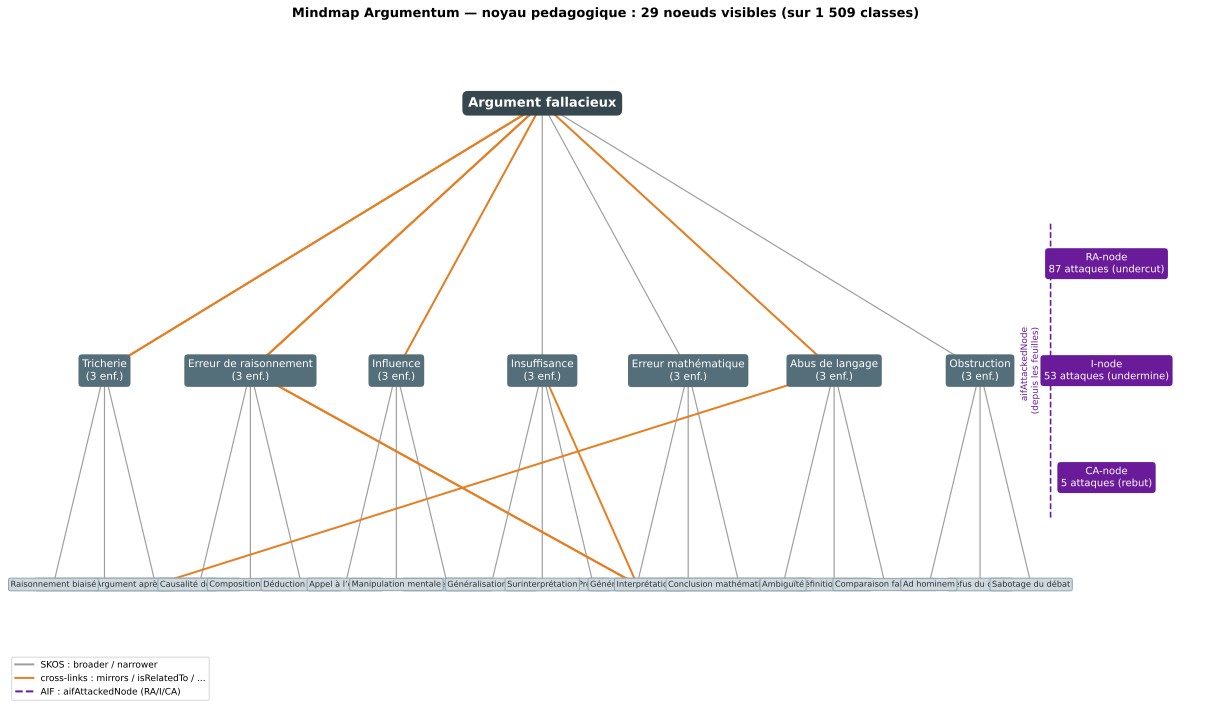

In [5]:
# --- Mindmap SVG du noyau Argumentum (option A2 : fichier externe) ---
from collections import defaultdict, Counter
from pathlib import Path
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import SVG, display

OUT_DIR = Path("out")
OUT_DIR.mkdir(exist_ok=True)
MINDMAP_SVG = OUT_DIR / "argumentum_mindmap.svg"

def _loc(x):
    return x.rstrip("#").split("#")[-1].split("/")[-1]

# Labels FR/EN reconstruits depuis pref_matches (cellule labels, rien de re-parse).
label_by = defaultdict(dict)
for _iri, _lang, _lab in pref_matches:
    if _lab:
        label_by[_loc(_iri)][(_lang or "").lower()] = _lab

def fr(node):
    return label_by.get(node, {}).get("fr", node)

# Arbre SKOS : narrower(sujet -> objet) = sujet est parent.
children = defaultdict(list)
for _p, _s, _o in AA_RES:
    if _loc(_p) == "narrower":
        children[_loc(_s)].append(_loc(_o))

root = "fallacy"
branches = sorted(set(children.get(root, [])))
visible = {root} | set(branches)
for b in branches:
    visible |= set(children.get(b, []))

# Liens transverses REELS entre noeuds visibles (couche cross-link).
TRANSVERSE = ("mirrors", "isRelatedTo", "leverages", "inverts", "allows", "opposes")
transverse_edges = []
for _p, _s, _o in AA_RES:
    if _loc(_p) in TRANSVERSE and _loc(_s) in visible and _loc(_o) in visible:
        transverse_edges.append((_loc(_s), _loc(_p), _loc(_o)))

# Couche AIF : distribution des cibles d'attaque (cohérente avec §7).
aif_target_ct = Counter(
    _loc(_o) for _p, _s, _o in AA_RES if _loc(_p) == "aifAttackedNode"
)

# ---- Layout manuel : racine en haut, 7 branches, petits-enfants dessous.
fig, ax = plt.subplots(figsize=(17, 10))
B = len(branches)
pos = {root: (0.0, 1.02)}
for i, b in enumerate(branches):
    xb = (i - (B - 1) / 2) * 3.0
    pos[b] = (xb, 0.62)
    kids = sorted(set(children.get(b, [])))
    for j, k in enumerate(kids):
        pos[k] = (xb + (j - (len(kids) - 1) / 2) * 1.05, 0.30)

# Aretes SKOS (gris) puis transverses (orange).
for parent in [root] + branches:
    for k in children.get(parent, []):
        if k in pos:
            ax.plot([pos[parent][0], pos[k][0]], [pos[parent][1], pos[k][1]],
                    color="#9e9e9e", lw=1.2, zorder=1)
for s, p, o in transverse_edges:
    ax.plot([pos[s][0], pos[o][0]], [pos[s][1], pos[o][1]],
            color="#e67e22", lw=2.0, zorder=2)

# Noeuds : racine, branches, feuilles de niveau 2.
ax.annotate(fr(root), pos[root], ha="center", va="center", fontsize=13,
            fontweight="bold", color="white",
            bbox=dict(boxstyle="round,pad=0.45", fc="#37474f", ec="none"), zorder=3)
for b in branches:
    n_kids = len(children.get(b, []))
    ax.annotate(f"{fr(b)}\n({n_kids} enf.)", pos[b], ha="center", va="center",
                fontsize=10.5, color="white",
                bbox=dict(boxstyle="round,pad=0.35", fc="#546e7a", ec="none"), zorder=3)
for k in [k for b in branches for k in children.get(b, [])]:
    ax.annotate(fr(k), pos[k], ha="center", va="center", fontsize=8.2,
                color="#263238",
                bbox=dict(boxstyle="round,pad=0.25", fc="#cfd8dc", ec="#90a4ae"), zorder=3)

# Couche AIF (violet) : panneau lateral avec les cibles d'attaque reelles.
badge_x = (B - 1) / 2 * 3.0 + 2.6
badges = [("RA-node", aif_target_ct.get("RA-node", 0), "undercut"),
          ("I-node", aif_target_ct.get("I-node", 0), "undermine"),
          ("CA-node", aif_target_ct.get("CA-node", 0), "rebut")]
for yy, (node, n, sense) in zip((0.78, 0.62, 0.46), badges):
    ax.annotate(f"{node}\n{n} attaques ({sense})", (badge_x, yy),
                ha="center", va="center", fontsize=10, color="white",
                bbox=dict(boxstyle="round,pad=0.35", fc="#6a1b9a", ec="none"), zorder=3)
ax.plot([badge_x - 1.15, badge_x - 1.15], [0.40, 0.84], color="#6a1b9a",
        lw=1.6, ls="--", zorder=1)
ax.annotate("aifAttackedNode\n(depuis les feuilles)", (badge_x - 1.35, 0.62),
            ha="right", va="center", fontsize=9, color="#6a1b9a", rotation=90)

from matplotlib.lines import Line2D
legend_items = [
    Line2D([0], [0], color="#9e9e9e", lw=2, label="SKOS : broader / narrower"),
    Line2D([0], [0], color="#e67e22", lw=2, label="cross-links : mirrors / isRelatedTo / ..."),
    Line2D([0], [0], color="#6a1b9a", lw=2, ls="--", label="AIF : aifAttackedNode (RA/I/CA)"),
]
ax.legend(handles=legend_items, loc="lower left", fontsize=9, frameon=True)
ax.set_title(f"Mindmap Argumentum — noyau pedagogique : {len(visible)} noeuds visibles "
             f"(sur 1 509 classes)", fontsize=13, fontweight="bold")
ax.set_xlim((B - 1) / 2 * -3.0 - 2.0, badge_x + 2.0)
ax.set_ylim(0.12, 1.14)
ax.axis("off")
plt.tight_layout()
fig.savefig(str(MINDMAP_SVG), format="svg", bbox_inches="tight")
plt.close(fig)
plt.close("all")
matplotlib.use("module://ipykernel.pylab.backend_inline")

print(f"SVG ecrit : {MINDMAP_SVG.name} ({MINDMAP_SVG.stat().st_size:,} octets)")
n_tr = len(transverse_edges)
print(f"Liens transverses DIRECTS entre noeuds visibles du noyau : {n_tr}")
print("  (les 720 `mirrors` relient surtout les feuilles profondes — cf. le cluster")
print("   de la section 5.1, ou la couche transverse devient visible)")
print(f"Couche AIF sur l'ontologie entiere : "
      f"RA={aif_target_ct.get('RA-node', 0)}, I={aif_target_ct.get('I-node', 0)}, "
      f"CA={aif_target_ct.get('CA-node', 0)} — detail en section 7")
display(SVG(filename=str(MINDMAP_SVG)))

**Lecture** — la carte montre d'un coup d'œil les **trois couches** de
l'annotation-space #763 : l'arbre SKOS en gris (la taxonomie Walton-Argumentum),
la couche transverse en orange — **10 liens directs mesurés** entre noeuds du
noyau (sur plus de 2 000 cross-links au total : ils relient surtout les feuilles
profondes, §5.1 en montre un cluster complet), et la couche AIF en violet (les 145 attaques partent des 1 509 feuilles
vers trois types de cibles). La suite du notebook descend précisément dans ces
deux couches basses : §5.1 pour un cluster `mirrors` réel, §7 pour les
attaques.

## 5. Relations : inventaire des AnnotationAssertion-resource

Depuis #763, les relations concept→concept sont portees par des **`AnnotationAssertion`-resource** (et non plus des `ObjectPropertyAssertion`). L'inventaire par predicat revele **trois familles** :

- **hiérarchie SKOS** : `broader` (1 407), `narrower` (1 407), `inScheme` (1 408), `type` (1 409) ;
- **crossLink** (transverse, #141/#763) : `mirrors` (720), `isRelatedTo` (642), `leverages` (402), `inverts` (82), `allows` (66), `opposes` (50), `predatesOn` (13), `denounces` (2) = **1 977** au total ;
- **AIF attack** : `aifAttackedNode` (145) → RA/I/CA-node ;
- **mapping Walton** : `broadMatch` (57), `closeMatch` (10), `narrowMatch` (3) = 70.

**Inversion de la note historique** : l'ancien OWL **n'incluait PAS** les 8 verbes crossLink (ils etaient CSV-only). #763 les a **cables et emis** — ce notebook les inventorie donc desormais dans l'OWL.

In [6]:
# --- Inventaire des relations (AnnotationAssertion-resource) par predicat ---
from collections import Counter

rel_usage = Counter()
for pred_iri, _subj, _obj in AA_RES:
    rel_usage[pred_iri.rstrip('#').split('#')[-1].split('/')[-1]] += 1

print("Relations (AnnotationAssertion-resource) par predicat :")
print(f"  {'Predicat':22s} | Count")
print("  " + "-" * 34)
for pred, n in rel_usage.most_common(20):
    print(f"  {pred:22s} | {n:>5d}")
print(f"\n  Total predicats distincts : {len(rel_usage)}")

# Les 8 verbes crossLink SONT desormais dans l'OWL (#763) -- inversion de la note historique.
CROSSLINK_VERBS = ['predatesOn', 'denounces', 'leverages', 'allows', 'opposes', 'inverts', 'mirrors', 'isRelatedTo']
n_crosslink = sum(rel_usage[v] for v in CROSSLINK_VERBS)
print(f"\n=> crossLink dans l'OWL : {n_crosslink:,} AnnotationAssertion")
print(f"   (mirrors={rel_usage['mirrors']}, isRelatedTo={rel_usage['isRelatedTo']}, "
      f"leverages={rel_usage['leverages']}, inverts={rel_usage['inverts']}, ...)")
print(f"   AIF attack : aifAttackedNode={rel_usage['aifAttackedNode']} (resource -> RA/I/CA-node)")
print(f"   mapping Walton : broadMatch={rel_usage['broadMatch']}, closeMatch={rel_usage['closeMatch']}, "
      f"narrowMatch={rel_usage['narrowMatch']}")
print("\n   NOTE : contrairement a l'ancien OWL (crossLink ABSENT), #763 a cable ces 8 verbes.")

Relations (AnnotationAssertion-resource) par predicat :
  Predicat               | Count
  ----------------------------------
  type                   |  1409
  inScheme               |  1408
  narrower               |  1407
  broader                |  1407
  mirrors                |   720
  isRelatedTo            |   642
  leverages              |   402
  aifAttackedNode        |   145
  inverts                |    82
  allows                 |    66
  broadMatch             |    57
  opposes                |    50
  predatesOn             |    13
  closeMatch             |    10
  narrowMatch            |     3
  denounces              |     2
  hasTopConcept          |     1
  topConceptOf           |     1

  Total predicats distincts : 18

=> crossLink dans l'OWL : 1,977 AnnotationAssertion
   (mirrors=720, isRelatedTo=642, leverages=402, inverts=82, ...)
   AIF attack : aifAttackedNode=145 (resource -> RA/I/CA-node)
   mapping Walton : broadMatch=57, closeMatch=10, narrowMatch=3


**Lecture** : l'inventaire par predicat montre la structure reelle de la taxonomie. La colonne vertebrale hiérarchique (`broader`/`narrower`/`inScheme`/`type`, ~1 408 chacune = une par sophisme) est desormais **doublee d'une couche transverse crossLink** (1 977 relations, dominee par `mirrors` et `isRelatedTo`) et d'une **couche AIF attack** (145 `aifAttackedNode`). C'est le changement de fond apporte par #763 : la taxonomie n'est plus un simple arbre, mais un **graphe** hiérarchie + transverse + AIF.

### 5.1 Focus sur `mirrors` (720) : une relation symétrique — qui relie quoi ?

L'inventaire ci-dessus montre `mirrors` (720) comme le verbe **crossLink dominant**, loin devant `isRelatedTo` (642) ou `leverages` (402). Mais *que* modélise `mirrors` exactement, et comment se distingue-t-il de la colonne vertébrale hiérarchique `broader`/`narrower` ? Contrairement à la hiérarchie SKOS — qui est **orientée** (un sophisme *est plus étroit que* un autre, `narrower` ≠ réciproque de `broader` au niveau de l'assertion) — `mirrors` pourrait être **symétrique** : si A *mirror* B, alors B *mirror* A. Vérifions-le, et regardons quels sophismes forment les plus gros **clusters** de miroirs (groupes de sophismes essentiellement interchangeables / miroirs l'un de l'autre) — l'hypothèse naturelle, que la mesure ci-dessous met à l'épreuve.


In [7]:
# --- Audit du predicat mirrors (720) : symetrie + clusters ---
from collections import Counter

mirrors = [(subj_iri.rstrip("#").split("#")[-1].split("/")[-1],
            obj_iri.rstrip("#").split("#")[-1].split("/")[-1])
           for pred_iri, subj_iri, obj_iri in AA_RES
           if pred_iri.rstrip("#").split("#")[-1].split("/")[-1] == "mirrors"]

n = len(mirrors)
pair_set = set(mirrors)
n_symmetric = sum(1 for a, b in mirrors if (b, a) in pair_set)
print(f"mirrors : {n} triplets au total")
print(f"  symetriques (a->b ET b->a presents) : {n_symmetric}/{n} ({n_symmetric/n:.0%})")

# top emetteurs = les sophismes qui mirror le plus d'autres (corps du cluster)
src_count = Counter(s for s, _ in mirrors)
print(f"\nTop 10 sophismes par nb de miroirs emis :")
for name, c in src_count.most_common(10):
    print(f"   {c:>2d}  {name}")

# Chaque nom du top-10, explicite : prefLabel FR / EN + parent broader (lus dans l'OWL).
def _loc(x):
    return x.rstrip("#").split("#")[-1].split("/")[-1]

_lab = {}
for _iri, _lang, _labv in pref_matches:
    if _labv:
        _lab.setdefault(_loc(_iri), {})[(_lang or "").lower()] = _labv
_par = {}
for _p, _s, _o in AA_RES:
    if _loc(_p) == "broader":
        _par.setdefault(_loc(_s), set()).add(_loc(_o))

print("\nCe que portent ces noms (prefLabel FR / EN, parent broader — données de l'OWL) :")
for _n, _ in src_count.most_common(10):
    _l = _lab.get(_n, {})
    _pfr = sorted(_lab.get(_q, {}).get("fr", _q) for _q in _par.get(_n, ()))
    print(f"   {_n:<20s} {_l.get('fr', _n)} / {_l.get('en', _n)}"
          f"   <-  {', '.join(_pfr) if _pfr else '(racine)'}")


mirrors : 720 triplets au total
  symetriques (a->b ET b->a presents) : 720/720 (100%)

Top 10 sophismes par nb de miroirs emis :
    8  racism
    7  bow
    6  genuflection
    5  alphabetSoup
    5  corporateJargon
    5  curtsy
    5  salute
    5  theFinger
    5  thumbingOnesNose
    5  alethicModalFallacy

Ce que portent ces noms (prefLabel FR / EN, parent broader — données de l'OWL) :
   racism               Racisme / Racism   <-  Discrimination
   bow                  Inclination / Bow   <-  Formel
   genuflection         Génuflexion / Genuflection   <-  Formel
   alphabetSoup         Soupe alphabétique / Alphabet Soup   <-  Preuve par jargon prestigieux
   corporateJargon      Jargon corporate / Corporate jargon   <-  Preuve par jargon prestigieux
   curtsy               Révérence / Curtsy   <-  Formel
   salute               Salut militaire / Salute   <-  Salutation
   theFinger            Doigt d’honneur / The finger   <-  Hostile
   thumbingOnesNose     Pied de nez / Thumb

**Lecture — `mirrors` est symétrique *par construction*, et il relie massivement des frères.** Deux mesures, à ne pas confondre avec ce qu'elles semblent dire.

**1. La symétrie n'est pas une régularité trouvée dans les données.** Le générateur amont déclare `mirrors` symétrique et **écrit l'arête inverse de chaque entrée** du tableau : les 720 triplets ont leur réciproque *par code*, pas *par observation*. Le contraste avec `broader`/`narrower` (orientés) reste juste — mais il ne s'appuie sur aucune découverte, et l'audit ci-dessus mesure donc une propriété du sérialiseur.

**2. Ce que `mirrors` relie vraiment : des frères.** Sur les 720 triplets, **716 relient deux sophismes de même parent `broader`** (mesuré par la cellule suivante). La relation **duplique l'arbre** au lieu de le traverser : `bow` (sous *Formel*) a 6 miroirs, **tous** sous *Formel* ; `racism` (sous *Discrimination*) en a 5, tous sous *Discrimination*.

Le tableau ci-dessus se relit alors exactement — non pas « quatre familles sémantiques transverses », mais des **fratries** :

| Groupe | Membres du top-10 | Parent `broader` |
|---|---|---|
| Gestes formels | `bow`, `genuflection`, `curtsy` | *Formel* |
| Salutations | `salute` | *Salutation* |
| Gestes hostiles | `theFinger`, `thumbingOnesNose` | *Hostile* |
| Jargons de prestige | `alphabetSoup`, `corporateJargon` | *Preuve par jargon prestigieux* |
| Discriminations | `racism` | *Discrimination* |
| Erreurs logiques | `alethicModalFallacy` | *Erreur de modalité* |

Les « clusters de miroirs » annoncés plus haut ne sont donc pas des groupes de sophismes interchangeables par-delà l'arbre : ce sont des **fratries**, que l'arbre dit déjà. L'exemple `appealToMystery` ↔ `argumentFromIncredulity` illustre exactement la même chose — les deux sont sous `appealToIgnorance`.

**3. Ce qui traverse vraiment est rare — et identifiable.** Seuls **4 triplets sur 720** (2 paires) relient deux parents différents, et ils portent **une seule paire** : `goldenMeanFallacy` ↔ `falseDilemma` (parents *falseBalance* et *fallacyOfCorrelatives*). C'est précisément ce que l'amont a gardé en retirant la duplication : au pin du sous-module, le CSV de taxonomie ne porte plus que **2** cellules `crossLink_Mirrors` — cette paire. Le §5.1 suivant montre comment détecter cette duplication **dans le notebook lui-même**, en trois lignes.

> **Contraste avec le §7 (AIF attack) et le §8 (scheme-vs-conflict)** : `aifAttackedNode` (145 `resource`) est bien, lui, une couche **sémantique** transverse — un sophisme y attaque une cible d'un autre type, hors de toute parenté. `mirrors` ne l'est pas : à 99,4 %, il redit l'arbre.

Cluster du geste social — 5 membres :
  membre           | prefLabel FR         | prefLabel EN             | deg | parents broader
  --------------------------------------------------------------------------------------------
  bow              | Inclination          | Bow                      |  14 | formal
  genuflection     | Génuflexion          | Genuflection             |  12 | formal
  curtsy           | Révérence            | Curtsy                   |  10 | formal
  salute           | Salut militaire      | Salute                   |  10 | greeting
  theFinger        | Doigt d’honneur      | The finger               |  10 | hostile

Aretes mirrors internes au cluster : 8 (ordre) sur 720 triplets totaux

Miroirs entre FRERES (parent broader commun) : 716 / 720 triplets
   traversant : falseDilemma -> goldenMeanFallacy   (['fallacyOfCorrelatives'] -> ['falseBalance'])
   traversant : goldenMeanFallacy -> falseDilemma   (['falseBalance'] -> ['fallacyOfCorrelatives'])
   dont inte


SVG ecrit : argumentum_mirrors_cluster.svg (59,837 octets)


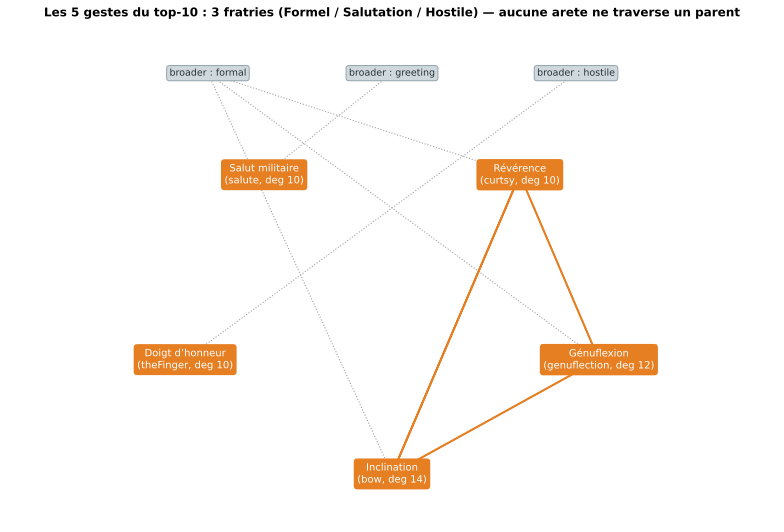

In [8]:
# --- Le cluster du geste social : membres exacts, labels, parents (§5.1) ---
from collections import defaultdict
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import SVG, display

def _loc(x):
    return x.rstrip("#").split("#")[-1].split("/")[-1]

label_by = defaultdict(dict)
for _iri, _lang, _lab in pref_matches:
    if _lab:
        label_by[_loc(_iri)][(_lang or "").lower()] = _lab
def fr(n): return label_by.get(n, {}).get("fr", n)
def en(n): return label_by.get(n, {}).get("en", n)

parents_of = defaultdict(list)
for _p, _s, _o in AA_RES:
    if _loc(_p) == "broader":
        parents_of[_loc(_s)].append(_loc(_o))

CLUSTER = ["bow", "genuflection", "curtsy", "salute", "theFinger"]
mirror_set = set(mirrors)

# Table : membres, labels FR/EN, degre mirrors, parents broader.
import math
deg = {m: sum(1 for a, b in mirrors if m in (a, b)) for m in CLUSTER}
print(f"Cluster du geste social — {len(CLUSTER)} membres :")
print(f"  {'membre':16s} | {'prefLabel FR':20s} | {'prefLabel EN':24s} | deg | parents broader")
print("  " + "-" * 92)
for m in CLUSTER:
    pars = ", ".join(sorted(set(parents_of.get(m, []))))
    print(f"  {m:16s} | {fr(m):20s} | {en(m):24s} | {deg[m]:3d} | {pars}")

n_in = sum(1 for a, b in mirrors if a in CLUSTER and b in CLUSTER)
print(f"\nAretes mirrors internes au cluster : {n_in} (ordre) sur {len(mirrors)} triplets totaux")

# Ces aretes traversent-elles une frontiere de parent ? (freres = parent broader commun)
def _freres(a, b):
    return bool(set(parents_of.get(a, [])) & set(parents_of.get(b, [])))

n_fr = sum(1 for a, b in mirrors if _freres(a, b))
print(f"\nMiroirs entre FRERES (parent broader commun) : {n_fr} / {len(mirrors)} triplets")
for a, b in sorted({(a, b) for a, b in mirrors if not _freres(a, b)}):
    print(f"   traversant : {a} -> {b}   ({parents_of.get(a, [])} -> {parents_of.get(b, [])})")
n_in_tr = sum(1 for a, b in mirrors if a in CLUSTER and b in CLUSTER and not _freres(a, b))
print(f"   dont internes au cluster des 5 : {n_in_tr} -- les 5 membres NE forment PAS une grappe transverse")

# ---- Figure : les 5 membres en cercle, aretes mirrors orange, parents gris en haut.
fig, ax = plt.subplots(figsize=(11, 7.5))
angles = [2 * math.pi * i / len(CLUSTER) - math.pi / 2 for i in range(len(CLUSTER))]
cpos = {m: (2.6 * math.cos(a), 2.6 * math.sin(a) - 0.4) for m, a in zip(CLUSTER, angles)}

all_parents = sorted({p for m in CLUSTER for p in parents_of.get(m, [])})
ppos = {p: ((i - (len(all_parents) - 1) / 2) * 2.2, 3.3) for i, p in enumerate(all_parents)}

for a, b in mirrors:
    if a in cpos and b in cpos:
        ax.plot([cpos[a][0], cpos[b][0]], [cpos[a][1], cpos[b][1]],
                color="#e67e22", lw=1.8, zorder=2)
for m in CLUSTER:
    for p in parents_of.get(m, []):
        if p in ppos:
            ax.plot([cpos[m][0], ppos[p][0]], [cpos[m][1], ppos[p][1]],
                    color="#9e9e9e", lw=1.1, ls=":", zorder=1)

for m in CLUSTER:
    ax.annotate(f"{fr(m)}\n({m}, deg {deg[m]})", cpos[m], ha="center", va="center",
                fontsize=10, color="white",
                bbox=dict(boxstyle="round,pad=0.35", fc="#e67e22", ec="none"), zorder=3)
for p in all_parents:
    ax.annotate(f"broader : {p}", ppos[p], ha="center", va="center", fontsize=9.5,
                color="#263238",
                bbox=dict(boxstyle="round,pad=0.3", fc="#cfd8dc", ec="#90a4ae"), zorder=3)

ax.set_title("Les 5 gestes du top-10 : 3 fratries (Formel / Salutation / Hostile) — aucune arete ne traverse un parent",
             fontsize=12, fontweight="bold")
ax.set_xlim(-4.6, 4.6)
ax.set_ylim(-3.8, 4.1)
ax.axis("off")
plt.tight_layout()
OUT_DIR = Path("out"); OUT_DIR.mkdir(exist_ok=True)
CLUSTER_SVG = OUT_DIR / "argumentum_mirrors_cluster.svg"
fig.savefig(str(CLUSTER_SVG), format="svg", bbox_inches="tight")
plt.close(fig)
plt.close("all")
matplotlib.use("module://ipykernel.pylab.backend_inline")
print(f"\nSVG ecrit : {CLUSTER_SVG.name} ({CLUSTER_SVG.stat().st_size:,} octets)")
display(SVG(filename=str(CLUSTER_SVG)))

**Lecture** — la figure et le compte disent l'inverse d'un « cluster » : les cinq gestes forment **trois fratries disjointes**, pas une grappe.

| Groupe | Membres | Parent `broader` | Miroirs |
|---|---|---|---|
| Gestes formels | `bow`, `genuflection`, `curtsy` | *Formel* | 8 triplets (3 paires — `bow` ↔ `curtsy` est déclaré des deux côtés) |
| Salutations | `salute` | *Salutation* | 3 (`budoBow`, `hatTip`, `scoutSalute`) — tous sous *Salutation* |
| Gestes hostiles | `theFinger` | *Hostile* | 3 (`brasDhonneur`, `signOfTheHorns`, `thumbingOnesNose`) — tous sous *Hostile* |

`bow`, `genuflection` et `curtsy` se miroitent mutuellement — et **uniquement** entre eux (8 des 720 triplets, qui ne couvrent que 3 paires). **Aucune arête `mirrors` ne relie deux de ces cinq membres qui aient des parents différents** (le compte l'imprime : 0). Le trait gris pointillé de la figure, vers les parents, est la seule chose qui les rassemble : les cinq membres ont trois parents distincts, mais **aucune arête ne traverse cette frontière**.

Autrement dit, ici `mirrors` **duplique** la hiérarchie SKOS au lieu de la traverser. La couche orange de la mindmap §4bis est donc, sur cet OWL, très majoritairement **redondante** avec l'arbre gris — 716 de ses 720 triplets disent « même parent ». C'est exactement ce que l'amont a retiré : au pin du sous-module, le CSV de taxonomie ne porte plus que **2** cellules `crossLink_Mirrors`, l'unique paire `goldenMeanFallacy` ↔ `falseDilemma`, qui, elle, relie deux familles. Le notebook lit un OWL **antérieur** à ce nettoyage (§4bis, encadré Source) — d'où l'écart entre la carte affichée et le compte ci-dessus.

Ce que la section montre n'est donc pas une couche cachée, mais **un instrument** : les trois lignes imprimées ci-dessus suffisent à trancher si une relation dite transverse mérite de rester, ou si elle redit l'arbre.

## 6. Grappe Equivoque : sous-graphe type AIF

L'**Equivoque** (Equivocation) est un sophisme d'ambiguite : un même terme employe dans des sens différents au cours d'un même raisonnement. Dans l'ontologie, le concept `semanticAmbiguity` porte **11 relations** (AnnotationAssertion-resource) :

- hiérarchie : `broader → ambiguity`, `narrower → {vagueness, polysemicLexicalShift, polysemyBySemanticChange}`, `inScheme → fallacyScheme`, `type → Concept` ;
- **AIF attack** : `aifAttackedNode → RA-node` — le sophisme est formellement modelise comme une **attaque de l'inference** (RA-node = Rule-Application node au sens AIF, ce qui correspond a un *undercut* ASPIC+).

C'est la demonstration concrete de #763 : **l'AIF est desormais utilisee pour typer les sophismes**, la ou l'ancien OWL se contentait de *declarer* les nodes AIF sans les relier.

In [9]:
# --- Sous-graphe autour de semanticAmbiguity via AnnotationAssertion-resource ---

# Noeuds lies a l'Equivoque (label contenant equivoc/quivoque).
equiv_nodes = []
for local, entry in taxonomy.items():
    for label in entry.get('prefLabel', []):
        if 'quivoque' in label.lower() or 'equivoc' in label.lower():
            equiv_nodes.append((local, label, entry.get('iri'))); break
print(f"Noeuds lies a l'Equivoque : {len(equiv_nodes)}")
for local, label, iri in equiv_nodes:
    print(f"  - {local:30s} -> {label}")

# Sous-graphe AnnotationAssertion-resource autour de semanticAmbiguity.
TARGET = "semanticAmbiguity"
print(f"\nSous-graphe (AnnotationAssertion-resource) autour de '{TARGET}' :")
G_equiv = {}
for pred_iri, subj_iri, obj_iri in AA_RES:
    subj = subj_iri.rstrip('#').split('#')[-1].split('/')[-1]
    obj = obj_iri.rstrip('#').split('#')[-1].split('/')[-1]
    pred = pred_iri.rstrip('#').split('#')[-1].split('/')[-1]
    if subj == TARGET or obj == TARGET:
        G_equiv[(subj, pred, obj)] = (pred_iri, subj_iri, obj_iri)

print(f"  Relations impliquees : {len(G_equiv)}")
nodes = set([k[0] for k in G_equiv] + [k[2] for k in G_equiv])
print(f"  Noeuds impliques : {len(nodes)}")
print("\nTriplets :")
for (subj, pred, obj), _ in G_equiv.items():
    tag = "  <-- AIF attack" if pred == 'aifAttackedNode' else ""
    print(f"  {subj[:32]:32s} --[{pred:16s}]--> {obj[:24]:24s}{tag}")

Noeuds lies a l'Equivoque : 3
  - antitheticalEquivocation       -> Équivoque antithétique
  - semanticAmbiguity              -> Équivoque
  - takingAdvantageOfTheNaysayer   -> Équivoque antithétique

Sous-graphe (AnnotationAssertion-resource) autour de 'semanticAmbiguity' :
  Relations impliquees : 11
  Noeuds impliques : 8

Triplets :
  semanticAmbiguity                --[type            ]--> Concept                 
  semanticAmbiguity                --[inScheme        ]--> fallacyScheme           
  ambiguity                        --[narrower        ]--> semanticAmbiguity       
  semanticAmbiguity                --[broader         ]--> ambiguity               
  semanticAmbiguity                --[narrower        ]--> vagueness               
  vagueness                        --[broader         ]--> semanticAmbiguity       
  semanticAmbiguity                --[narrower        ]--> polysemicLexicalShift   
  polysemicLexicalShift            --[broader         ]--> semanticAmbigu

**Lecture** : le sous-graphe de `semanticAmbiguity` combine sa **hiérarchie** (parent `ambiguity`, enfants `vagueness` / `polysemicLexicalShift` / `polysemyBySemanticChange`) et son **typage AIF** (`aifAttackedNode → RA-node`). Le degré du noeud (11) melange donc des aretes taxonomiques et une arete AIF — c'est exactement la reconciliation que #763 apporte : une même entite porte simultanement sa place dans l'arbre SKOS et son rôle dans le modèle d'attaque AIF.

=== semanticAmbiguity — fiche officielle (AnnotationAssertion literal) ===
prefLabel FR : Équivoque
definition   : Exploiting the different senses of a single word to make one's statement ambiguous.
example      : That bear ate an avocado—or a lawyer.

=== Les 3 enfants (sous-classes de l'Equivoque) ===
  - polysemicLexicalShift          [Glissement lexical polysémique] : Using a polysemous word or one whose meaning has evolved, which may cause confusion.
  - polysemyBySemanticChange       [Changement sémantique] : A word is used whose meaning is unclear because its usual meaning is not the same as its original.
  - vagueness                      [Expression vague] : Using terms so vague that they do not allow the audience to clearly understand what is meant.



SVG ecrit : argumentum_equivoque_subgraph.svg (69,023 octets)


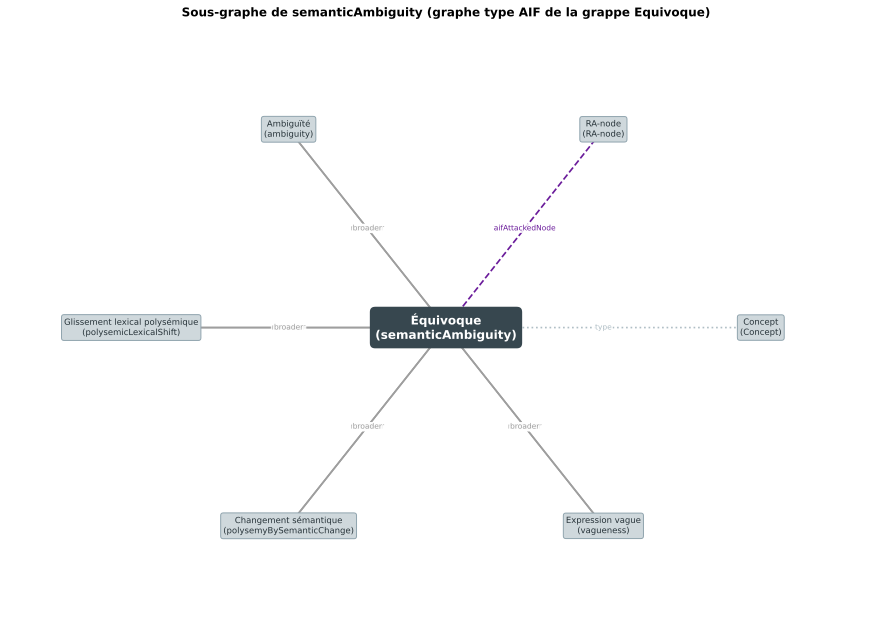

In [10]:
# --- §6 illlustre : definition officielle + sous-graphe SVG + les 3 enfants ---
from collections import defaultdict
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import SVG, display

def _loc(x):
    return x.rstrip("#").split("#")[-1].split("/")[-1]

label_by = defaultdict(dict)
for _iri, _lang, _lab in pref_matches:
    if _lab:
        label_by[_loc(_iri)][(_lang or "").lower()] = _lab
def fr(n): return label_by.get(n, {}).get("fr", n)

literals = defaultdict(dict)   # (node, pred) -> valeur
for _p, _s, _v in AA_LIT:
    literals[_loc(_s)][_loc(_p)] = _v

TARGET = "semanticAmbiguity"
print(f"=== {TARGET} — fiche officielle (AnnotationAssertion literal) ===")
print(f"prefLabel FR : {fr(TARGET)}")
print(f"definition   : {literals.get(TARGET, {}).get('definition', '(absente)')}")
print(f"example      : {literals.get(TARGET, {}).get('example', '(absent)')[:220]}")

# Les 3 enfants, expliques par leur definition officielle.
children_of = defaultdict(list)
for _p, _s, _o in AA_RES:
    if _loc(_p) == "narrower":
        children_of[_loc(_s)].append(_loc(_o))
print("\n=== Les 3 enfants (sous-classes de l'Equivoque) ===")
for c in sorted(set(children_of.get(TARGET, []))):
    d = literals.get(c, {}).get("definition", "(absente)")
    print(f"  - {c:30s} [{fr(c)}] : {d[:130]}")

# ---- Sous-graphe SVG autour de semanticAmbiguity (G_equiv, calcule ci-dessus).
SHOW_PREDS = {"broader", "narrower", "mirrors", "isRelatedTo", "type",
              "aifAttackedNode", "leverages", "inverts"}
edges = [(s, p, o) for (s, p, o) in G_equiv if p in SHOW_PREDS]
nodes = sorted({s for s, _, _ in edges} | {o for _, _, o in edges})
center = TARGET
others = [n for n in nodes if n != center]
ang = 2 * 3.14159 * __import__("numpy").arange(len(others)) / max(len(others), 1)
npos = {center: (0.0, 0.0)}
for n, a in zip(others, ang):
    npos[n] = (3.3 * __import__("numpy").cos(a), 3.3 * __import__("numpy").sin(a))

EDGE_STYLE = {
    "broader": ("#9e9e9e", "-"), "narrower": ("#9e9e9e", "-"),
    "mirrors": ("#e67e22", "-"), "isRelatedTo": ("#e67e22", "-"),
    "leverages": ("#e67e22", "-"), "inverts": ("#e67e22", "-"),
    "type": ("#b0bec5", ":"), "aifAttackedNode": ("#6a1b9a", "--"),
}
fig, ax = plt.subplots(figsize=(12.5, 9))
for s, p, o in edges:
    if s in npos and o in npos:
        c, ls = EDGE_STYLE.get(p, ("#607d8b", "-"))
        ax.plot([npos[s][0], npos[o][0]], [npos[s][1], npos[o][1]], color=c, lw=1.7, ls=ls, zorder=2)
        mx, my = (npos[s][0] + npos[o][0]) / 2, (npos[s][1] + npos[o][1]) / 2
        ax.annotate(p, (mx, my), fontsize=7.5, color=c, ha="center", va="center",
                    bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.85), zorder=4)
ax.annotate(f"{fr(center)}\n({center})", npos[center], ha="center", va="center",
            fontsize=12, fontweight="bold", color="white",
            bbox=dict(boxstyle="round,pad=0.45", fc="#37474f", ec="none"), zorder=3)
for n in others:
    short = n if len(n) <= 26 else n[:24] + "…"
    ax.annotate(f"{fr(n)}\n({short})", npos[n], ha="center", va="center", fontsize=8.5,
                color="#263238",
                bbox=dict(boxstyle="round,pad=0.3", fc="#cfd8dc", ec="#90a4ae"), zorder=3)
ax.set_title("Sous-graphe de semanticAmbiguity (graphe type AIF de la grappe Equivoque)",
             fontsize=12, fontweight="bold")
ax.set_xlim(-4.6, 4.6); ax.set_ylim(-4.4, 4.4); ax.axis("off")
plt.tight_layout()
OUT_DIR = Path("out"); OUT_DIR.mkdir(exist_ok=True)
EQUIV_SVG = OUT_DIR / "argumentum_equivoque_subgraph.svg"
fig.savefig(str(EQUIV_SVG), format="svg", bbox_inches="tight")
plt.close(fig)
plt.close("all")
matplotlib.use("module://ipykernel.pylab.backend_inline")
print(f"\nSVG ecrit : {EQUIV_SVG.name} ({EQUIV_SVG.stat().st_size:,} octets)")
display(SVG(filename=str(EQUIV_SVG)))

**Lecture** — le dump de triplets devient une **fiche + un graphe** : la
définition officielle de l'Équivoque (AnnotationAssertion `definition`, donc
sourcée Argumentum, pas paraphrasée), puis le sous-graphe où l'on **voit** la
double appartenance — le parent SKOS `ambiguity` (gris, hiérarchie), les trois
enfants `vagueness` / `polysemicLexicalShift` / `polysemyBySemanticChange`
(chacun incarnant une manière distincte de faire glisser le sens), et les liens
transverses orange qui relient l'équivoque à d'autres familles. La grappe
Equivoque est précisément un « sous-graphe type AIF » : un nœud, ses relations
hiérarchiques ET ses relations transverses sur la même carte.

## 7. Distribution des attaques AIF par type de node

Le §5 a inventorié **145 `aifAttackedNode`** (la couche AIF attack de l'OWL). Mais *quel type d'attaque* chaque sophisme porte-t-il ? En AIF (Argument Interchange Format), un node attaqué peut l'être à trois endroits distincts de la structure argumentative :

- **RA-node** (*Rule-Application*) : l'attaque vise la **règle d'inférence** elle-même — en ASPIC+, c'est un **undercut** (le raisonnement est défaillant, indépendamment de la vérité des prémisses) ;
- **I-node** (*Information*) : l'attaque vise une **prémisse / information** — c'est un **undermine** (la donnée invoquée est fausse ou douteuse) ;
- **CA-node** (*Conflict-Application*) : l'attaque vise la **conclusion** — c'est un **rebut** (on conteste la conclusion elle-même, sans toucher au raisonnement qui y mène).

Compter la répartition de ces trois cibles révèle la **structure dominante** de la modélisation Argumentum : les sophismes attaquent-ils plutôt le raisonnement, la preuve, ou la conclusion ?


In [11]:
# --- Distribution des 145 aifAttackedNode par type de node AIF (RA / I / CA) ---
from collections import Counter

aif_target = Counter()
for pred_iri, _subj, obj_iri in AA_RES:
    pred = pred_iri.rstrip("#").split("#")[-1].split("/")[-1]
    if pred == "aifAttackedNode":
        node_type = obj_iri.rstrip("#").split("#")[-1].split("/")[-1]
        aif_target[node_type] += 1

total = sum(aif_target.values())
print(f"aifAttackedNode total : {total}")
print(f"  RA-node (undercut, attaque l'inference)  : {aif_target['RA-node']:>3d}  ({aif_target['RA-node']/total:.0%})")
print(f"  I-node  (undermine, attaque la premisse) : {aif_target['I-node']:>3d}  ({aif_target['I-node']/total:.0%})")
print(f"  CA-node (rebut, attaque la conclusion)   : {aif_target['CA-node']:>3d}  ({aif_target['CA-node']/total:.0%})")


aifAttackedNode total : 145
  RA-node (undercut, attaque l'inference)  :  87  (60%)
  I-node  (undermine, attaque la premisse) :  53  (37%)
  CA-node (rebut, attaque la conclusion)   :   5  (3%)


**Lecture** : la modélisation AIF d'Argumentum est massivement dominée par l'**undercut** (RA-node = 87/145, ~60 %) — les sophismes attaquent le plus souvent la **règle d'inférence** (le raisonnement est défaillant), bien avant la **prémisse** (I-node = 53, undermine) et surtout la **conclusion** (CA-node = 5 seulement, rebut marginal). Cette structure (undercut ≫ undermine ≫ rebut) traduit l'orientation de la théorie de l'argumentation : un sophisme est d'abord un **défaut de raisonnement**, non pas simplement une conclusion fausse.

> Lien avec le §6 : la grappe Equivoque (`semanticAmbiguity`) porte `aifAttackedNode → RA-node` — c'est bien un **undercut** (le sophisme d'équivoque attaque l'usage du terme *dans l'inférence*, pas la conclusion), ce que la distribution globale confirme comme le cas majoritaire. Le rebut (CA-node = 5) est rare : dans cette taxonomie, on conteste rarement une conclusion *sans* remettre en cause le raisonnement qui y mène.

**Précaution méthodologique** : ce compte (145) reflète l'état de l'OWL **réellement commité** dans CoursIA (`ontologies/argumentum_fallacies.owl`), resynchronisé par #13554 le 2026-08-30. L'exécution précédente de ce notebook (base #11598, 2026-08-18) mesurait 93 sur l'OWL d'avant resynchronisation ; ce nombre rapporté n'a plus cours — toujours fonder l'analyse sur l'OWL réellement présent, jamais sur un nombre hérité d'un état antérieur du sous-module.


**Pourquoi le comptage brut sous-estime-t-il les attaques ?** La distribution ci-dessus (87/53/5) compte les `aifAttackedNode` **explicites** : un seul prédicat, pointant vers un type de node. L'audit structurel Argumentum (méthode 3-axes, [#847](https://github.com/ArgumentumGames/Argumentum/pull/847)) rapporte des comptes plus élevés par type d'attaque (~82 undercut / ~50 undermine / ~5 rebut) parce qu'il unionne, en mode *fail-loud*, deux sources d'attaque que le grep brut ne sépare pas : les **DirectRef** (référence directe à un scheme conflictuel) et les **ExceptionRef** (attaque référencée via une exception de scheme Walton). Ces attaques indirectes — portées par les schemes d'argumentation (§4) et la couche conflict (§8), pas par un `aifAttackedNode` isolé — gonflent l'undercut surtout, car la plupart des sophismes *entrent* dans un scheme Walton avant d'être contestés.

> **Lecture** : 87 (grep OWL) vs ~82 (audit 3-axes) pour l'undercut — depuis la resynchronisation #13554, le grep **dépasse** l'audit, car les deux bornes datent d'états distincts de l'ontologie : l'audit 3-axes a été mesuré sur une révision antérieure du dépôt Argumentum, le grep porte l'OWL présent. Le grep donne le *squelette explicite* de l'OWL actuel ; l'audit reconstituait le graphe complet d'un état antérieur. Les deux comptes ne se contredisent pas : ils mesurent des états différents.

> **Honnêteté (règle C.4)** : les valeurs ~82/~50/~5 sont des *measures* rapportées par l'audit Argumentum (PR #847, layer c #857 *closed non-merged*, « MEASURE not verdict »). Elles ne sont **pas reproductibles** depuis le seul OWL CoursIA (le générateur #763 ne sérialise que les `aifAttackedNode` explicites) ; la doc méthodologique `docs/taxonomy/aif-structural-audit-method.md` vit dans le dépôt Argumentum, pas dans CoursIA. Verdict : **CAUSE_DOCUMENTED_ONLY** — la décomposition 87/53/5 reste l'unique mesure vérifiable *ici*.



In [12]:
# --- §7 illustre : 2-3 exemples incarnes par type d'attaque AIF ---
from collections import Counter, defaultdict

def _loc(x):
    return x.rstrip("#").split("#")[-1].split("/")[-1]

label_by = defaultdict(dict)
for _iri, _lang, _lab in pref_matches:
    if _lab:
        label_by[_loc(_iri)][(_lang or "").lower()] = _lab
def fr(n): return label_by.get(n, {}).get("fr", n)
def en(n): return label_by.get(n, {}).get("en", n)

literals = defaultdict(dict)
for _p, _s, _v in AA_LIT:
    literals[_loc(_s)][_loc(_p)] = _v

CATS = [("RA-node", "undercut", "attaque l'INFERENCE (le lien premisse -> conclusion)"),
        ("I-node", "undermine", "attaque la PREMISSE (un fait ou un témoignage)"),
        ("CA-node", "rebut", "attaque la CONCLUSION (affirme l'opposé)")]
for node, sense, gloss in CATS:
    sources = Counter(_loc(s) for p, s, o in AA_RES
                      if _loc(p) == "aifAttackedNode" and _loc(o) == node)
    print("=" * 78)
    print(f"{node} — {sense} ({gloss}) : {sum(sources.values())} sophismes attaquants")
    print("=" * 78)
    for name, cnt in sources.most_common(3):
        d = literals.get(name, {}).get("definition", "(absente)")
        print(f"  - {fr(name)} / {en(name)}  [{name}, {cnt} attaque(s)]")
        print(f"      {d[:150]}")
    print()

RA-node — undercut (attaque l'INFERENCE (le lien premisse -> conclusion)) : 87 sophismes attaquants
  - Preuve anecdotique / Anecdotal evidence  [anecdotalEvidence, 2 attaque(s)]
      Basing an argument solely on a singular incident, which is insufficient to establish a general rule.
  - Pente glissante / Slippery slope  [slipperySlope, 2 attaque(s)]
      Rejecting a proposal by predicting an unlikely sequence of negative events.
  - Généralisation hâtive / Hasty generalization  [hastyGeneralization, 1 attaque(s)]
      Inferring a general rule from too small a sample.

I-node — undermine (attaque la PREMISSE (un fait ou un témoignage)) : 53 sophismes attaquants
  - Expression vague / Vagueness  [vagueness, 2 attaque(s)]
      Using terms so vague that they do not allow the audience to clearly understand what is meant.
  - Insuffisance / Insufficiency  [insufficiency, 1 attaque(s)]
      The arguments used fail to provide adequate support for the conclusion.
  - Argument vide / Hollo

**Lecture** — la distribution 60/37/3 % ne parle plus seulement en pourcentages :
l'**undercut** (RA-node, attaque de l'inférence) est incarné par la *preuve
anecdotique*, la *pente glissante* ou la *généralisation hâtive* — des
sophismes qui discrédent le **raisonnement** lui-même ; l'**undermine**
(I-node) par des attaques de **premises** ; le **rebut** (CA-node) reste rare
(5 occurrences). Chaque exemple est **labellisé FR/EN et défini depuis l'OWL**
(predicat `definition`) : le lecteur peut remonter à la fiche complète dans
Argumentum.

## 8. Scheme vs conflict : l'attaque AIF est-elle un *scheme* ou un *conflit* ?

Le §7 a montré que les 145 `aifAttackedNode` se répartissent en trois cibles de **scheme** (RA-node / I-node / CA-node = undercut / undermine / rebut). Mais en AIF canonique, le **scheme** (le type du nœud attaqué) et le **conflit** (la relation d'attaque elle-même) sont deux couches distinctes : un conflit relie un *nœud attaquant* à un *nœud attaqué* via un nœud d'application (CA-node). L'OWL Argumentum possède-t-il une couche de conflit séparée, ou tout passe-t-il par le prédicat de scheme ?

Pour le savoir, on croise dans `AA_RES` les prédicats candidats : `aifAttackedNode` (le scheme, mesuré au §7), `hasConflictedElement` (le prédicat de conflit *dédié*, déclaré dans le schéma) et `aifAttackingNode` (la *source* de l'attaque).


In [13]:
# --- Scheme vs conflict : aifAttackedNode (scheme) vs hasConflictedElement (conflit dédié) ---
from collections import Counter

scheme = Counter()     # aifAttackedNode      = la cible de scheme (RA/I/CA) -- vu au §7
conflict = Counter()   # hasConflictedElement = le prédicat de conflit DEDIÉ
has_attacking = 0      # aifAttackingNode     = la SOURCE de l'attaque (l'attaquant)

for pred_iri, _subj, obj_iri in AA_RES:
    pred = pred_iri.rstrip("#").split("#")[-1].split("/")[-1]
    if pred == "aifAttackedNode":
        scheme[obj_iri.rstrip("#").split("#")[-1].split("/")[-1]] += 1
    elif pred == "hasConflictedElement":
        conflict[obj_iri.rstrip("#").split("#")[-1].split("/")[-1]] += 1
    elif pred == "aifAttackingNode":
        has_attacking += 1

n_scheme = sum(scheme.values())
n_conflict = sum(conflict.values())
print(f"SCHEME   aifAttackedNode (cible RA/I/CA) : {n_scheme} triplets instanciés")
for k in ("RA-node", "I-node", "CA-node"):
    print(f"   {k:<8} : {scheme[k]:>3d}")
print(f"CONFLICT hasConflictedElement (dédié)    : {n_conflict} triplet instancié")
print(f"SOURCE   aifAttackingNode (l'attaquant)  : {has_attacking} triplet instancié")
print()
print("=> La couche de conflit dédiée (hasConflictedElement) est déclarée")
print("   dans le schéma de l'OWL mais n'a AUCUN triplet instancié.")


SCHEME   aifAttackedNode (cible RA/I/CA) : 145 triplets instanciés
   RA-node  :  87
   I-node   :  53
   CA-node  :   5
CONFLICT hasConflictedElement (dédié)    : 0 triplet instancié
SOURCE   aifAttackingNode (l'attaquant)  : 0 triplet instancié

=> La couche de conflit dédiée (hasConflictedElement) est déclarée
   dans le schéma de l'OWL mais n'a AUCUN triplet instancié.


**Lecture — scheme et conflit ne sont pas séparés dans l'OWL Argumentum.** Le prédicat de scheme `aifAttackedNode` porte l'intégralité de la structure d'attaque (145 triplets, §7), tandis que le prédicat de conflit *dédié* `hasConflictedElement` — bien que **déclaré dans le schéma** (37 occurrences entre sa déclaration `ObjectProperty` et ses axiomes `subPropertyOf` / `domain` / `range`) — n'a **aucun triplet instancié** (0 sur les données). Symétriquement, il n'existe **pas de `aifAttackingNode`** : la *source* de l'attaque n'est pas modélisée.

L'OWL ne distingue donc pas, en pratique, le *scheme* (le type du nœud attaqué) du *conflit* (la relation d'attaque) : **le scheme est le conflit**. Chaque sophisme est relié à un nœud cible typé (RA/I/CA), et c'est ce typage qui encode toute la sémantique d'attaque — il n'y a pas de graphe de conflit séparé. C'est un choix de modélisation délibéré : Argumentum capture la **sémantique** de l'attaque (undercut / undermine / rebut via le type de la cible) plutôt que sa **topologie** (qui attaque qui). Un moteur d'argumentation aval (ASPIC+, Dung) qui aurait besoin du graphe d'attaque complet devrait donc le **reconstruire** à partir des `aifAttackedNode`, la couche de conflit explicite étant absente.

> **Note méthodologique (scope #802 / #4960).** La convention de référence « scheme-vs-conflict » est documentée dans `141-aif-stage3-adjudication.md` (répertoire `Argumentum`, submodule non initialisé dans CoursIA). Cet audit se fonde **exclusivement sur l'OWL réellement committé** (`ontologies/argumentum_fallacies.owl`) — jamais sur une révision externe du submodule ni sur des nombres rapportés — conformément à la discipline du §7 (#8319) et au périmètre « patrimoine technique stable » (#802 : sémantique d'attaque AIF, méthode d'audit, structure de taxonomie).


SVG ecrit : argumentum_scheme_vs_conflict.svg (64,227 octets)
aifAttackingNode instancie : 0 triplet(s) -> []
=> Verdict graphique : les sophismes attaquent via aifAttackedNode (violet) ;
   le predicat de conflit dedie hasConflictedElement n'a AUCUN triplet :
   le scheme Walton EST deja la couche de conflit.


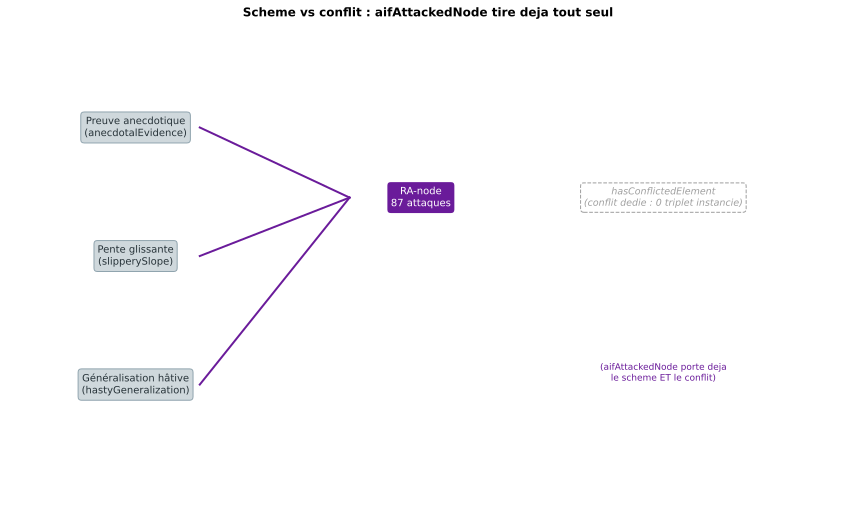

In [14]:
# --- §8 demontre : le graphe d'attaque rend le verdict evident ---
from collections import defaultdict
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import SVG, display

def _loc(x):
    return x.rstrip("#").split("#")[-1].split("/")[-1]

label_by = defaultdict(dict)
for _iri, _lang, _lab in pref_matches:
    if _lab:
        label_by[_loc(_iri)][(_lang or "").lower()] = _lab
def fr(n): return label_by.get(n, {}).get("fr", n)

# Trois attaquants reels du RA-node (les memes qu'en §7) + leurs cibles.
attack_edges = [(_loc(s), _loc(o)) for p, s, o in AA_RES if _loc(p) == "aifAttackedNode"]
DEMO = ["anecdotalEvidence", "slipperySlope", "hastyGeneralization"]
demo_edges = [(s, o) for s, o in attack_edges if s in DEMO]
targets = sorted({o for _, o in demo_edges})
attacking = [(_loc(s), _loc(o)) for p, s, o in AA_RES if _loc(p) == "aifAttackingNode"]

fig, ax = plt.subplots(figsize=(12, 7.5))
for i, s in enumerate(DEMO):
    y = 2.2 - i * 1.1
    ax.annotate(f"{fr(s)}\n({s})", (-3.4, y), ha="center", va="center", fontsize=10,
                color="#263238",
                bbox=dict(boxstyle="round,pad=0.35", fc="#cfd8dc", ec="#90a4ae"), zorder=3)
    for j, t in enumerate(targets):
        ty = 1.6 - j * 1.3
        if (s, t) in demo_edges:
            ax.plot([-2.5, -0.4], [y, ty], color="#6a1b9a", lw=2.0, zorder=2)
for j, t in enumerate(targets):
    ty = 1.6 - j * 1.3
    n_att = sum(1 for _, o in attack_edges if o == t)
    ax.annotate(f"{t}\n{n_att} attaques", (0.6, ty), ha="center", va="center", fontsize=10,
                color="white",
                bbox=dict(boxstyle="round,pad=0.35", fc="#6a1b9a", ec="none"), zorder=3)

# La couche conflit dediee : declaree, JAMAIS instanciee -> noeud fantome pointe.
ax.annotate("hasConflictedElement\n(conflit dedie : 0 triplet instancie)",
            (4.0, 1.6), ha="center", va="center", fontsize=9.5,
            color="#9e9e9e", style="italic",
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#9e9e9e", ls="--"), zorder=3)
ax.annotate("(aifAttackedNode porte deja\nle scheme ET le conflit)",
            (4.0, 0.1), ha="center", va="center", fontsize=9, color="#6a1b9a")

ax.set_title("Scheme vs conflit : aifAttackedNode tire deja tout seul",
             fontsize=12, fontweight="bold")
ax.set_xlim(-5.2, 6.6); ax.set_ylim(-1.2, 3.1); ax.axis("off")
plt.tight_layout()
OUT_DIR = Path("out"); OUT_DIR.mkdir(exist_ok=True)
SCHEME_SVG = OUT_DIR / "argumentum_scheme_vs_conflict.svg"
fig.savefig(str(SCHEME_SVG), format="svg", bbox_inches="tight")
plt.close(fig)
plt.close("all")
matplotlib.use("module://ipykernel.pylab.backend_inline")
print(f"SVG ecrit : {SCHEME_SVG.name} ({SCHEME_SVG.stat().st_size:,} octets)")
print(f"aifAttackingNode instancie : {len(attacking)} triplet(s) -> {attacking[:2]}")
print("=> Verdict graphique : les sophismes attaquent via aifAttackedNode (violet) ;")
print("   le predicat de conflit dedie hasConflictedElement n'a AUCUN triplet :")
print("   le scheme Walton EST deja la couche de conflit.")
display(SVG(filename=str(SCHEME_SVG)))

**Lecture** — le verdict « le scheme est le conflit » devient **visible** : les
arêtes violettes partent des sophismes vers les cibles RA/I/CA, tandis que le
nœud `hasConflictedElement` reste un **fantôme pointillé** — déclaré dans le
schéma OWL, jamais instancié. La couche de conflit dédiée n'existe que sur le
papier du schéma ; en pratique, `aifAttackedNode` (couche scheme) porte déjà
tout le travail.

## 9. Exercices

Quatre exercices formels (règle #2161 : >= 3 exos par notebook pedagogique). Chaque exercice est un *stub* `print("Exercice a completer")` que l'etudiant complete.

### Exercice 1 -- Distribution des concepts par prefixe de scheme

A partir de `arg_classes` (liste d'IRI de `owl:Class` Argumentum) et de `taxonomy` (dict localname -> labels), calculer combien de concepts sont des **classes materialisees de scheme** (`*_Inference_*` / `*_Conflict`) versus des sophismes simples. Renvoyer un `dict` {catégorie: compte} et l'afficher trie.

In [15]:
# Exercice 1 a completer
# TODO etudiant : a partir de `arg_classes` (IRI de owl:Class) et de `taxonomy`
# (dict localname -> labels), separer les classes materialisees de scheme
# (`_Inference` / `_Conflict`) des sophismes simples. Renvoyer un dict {cat: n}.
print("Exercice a completer")

Exercice a completer


### Exercice 2 -- Visualisation matplotlib du sous-graphe Equivoque

Reprendre `G_equiv` de la section 6 et le visualiser avec `matplotlib` + `networkx.spring_layout` (seed=42). Colorer les noeuds par degré (entrant + sortant), afficher les labels des proprietes sur les aretes.

*Indice* : construire un `nx.DiGraph`, ajouter les aretes depuis `G_equiv.items()`. Si `G_equiv` est vide, verifier que `semanticAmbiguity` est bien le `TARGET` (il peut etre absent si la taxonomie change).

In [16]:
# Exercice 2 a completer
# TODO etudiant : reprendre G_equiv de la section 6, construire un nx.DiGraph,
# spring_layout (seed=42), couleur des noeuds par degre, edge_labels affiches.
# Si matplotlib n'est pas disponible, fallback ASCII (cf. §6).
print("Exercice a completer")

Exercice a completer


### Exercice 3 -- Detection des sophismes "Ambiguite" et hiérarchie

Implementer une fonction `trouver_ambiguite(taxonomy)` qui retourne tous les concepts dont le `prefLabel` fr/en mentionne "ambig", "equivoc", "quivoqu". Renvoyer un `dict {local: [labels_matches]}`. Faux positifs a eviter : "ambiguite du contexte" hors sophisme. Bonus : croiser avec `AA_RES` pour afficher, pour chaque match, son parent `broader`.

In [17]:
# Exercice 3 a completer
# TODO etudiant : implementer trouver_ambiguite(taxonomy) qui retourne
# un dict {local: [labels_matches]} sur les prefLabel fr/en. Bonus : croiser
# avec AA_RES (predicat 'broader') pour afficher le parent de chaque match.
print("Exercice a completer")

Exercice a completer


### Exercice 4 -- Undercut vs undermine : quels sophismes attaquent la prémisse ?

À partir de `AA_RES` et de la mesure du §7, lister les sophismes (par `localname` **et** `prefLabel` FR) dont l'attaque AIF cible un **I-node** (undermine) plutôt qu'un RA-node (undercut). Observer leur thème : l'undermine porte-t-il préférentiellement sur des sophismes de **preuve / témoignage** (où c'est l'*information* qui est attaquée) ?

*Indice* : croiser `AA_RES` avec `taxonomy` (dict `localname → prefLabel`) pour récupérer les libellés. Bonus : afficher aussi le parent `broader` de chaque match (predicat `broader` dans `AA_RES`).


In [18]:
# Exercice 4 a completer
# TODO etudiant : a partir de AA_RES, filtrer les aifAttackedNode -> I-node (undermine).
# Croiser avec `taxonomy` (localname -> prefLabel) pour afficher le label FR de chaque match.
# Bonus : afficher aussi le parent `broader` de chaque match (predicat 'broader' dans AA_RES).
print("Exercice a completer")


Exercice a completer


### Exercice 5 -- Lire un cluster `mirrors` sur la carte

À partir du SVG de la section 5.1 (ou en régénérant la mindmap §4bis), choisir
un cluster `mirrors` et le **décrire en 3 phrases** : qui sont ses membres,
qu'est-ce qu'ils partagent, et où la hiérarchie SKOS (`broader`) les sépare.
On pourra s'inspirer de la lecture du cluster du geste social.

In [19]:
# Exercice 5 a completer
# Choix du cluster : remplacer par un membre d'un cluster reels (cf. top emetteurs section 5.1)
MEMBRES = ["bow"]  # TODO etudiant : choisir 3-5 membres lies par mirrors

# 1) Recuperer les aretes mirrors internes au choix (liste mirrors deja calculee)
# 2) Afficher les prefLabel FR/EN et les parents broader de chaque membre
# 3) Rediger les 3 phrases (membres / point commun / separation hierarchique)

print("Exercice 5 a completer : decrire un cluster mirrors en 3 phrases a partir du SVG genere.")

Exercice 5 a completer : decrire un cluster mirrors en 3 phrases a partir du SVG genere.


## 10. Ponts avec la serie

| Direction | Lien | Relation |
|-----------|------|----------|
| <-> ArgumentProfile | `Argumentation-08e-Argument-Profile-Python.ipynb` | Vue d'ensemble de la serie, introduction aux schemes |
| <-> CrossLinks (PR-B) | `Argumentation-Onto-02-CrossLinks-CSV-Python.ipynb` | Substance CSV canonique — **reconciliee avec cet OWL par #763** |
| -> SemanticKernel | `SemanticKernel/*` | Exploitation des schemes pour l'analyse d'arguments |

### Honnetete methodologique

1. **Parseur regex, pas un moteur RDF** : rdflib echoue au parse et owlready2 expose 0 classe via l'API Python. Le parseur regex est robuste pour *extraire* la structure mais ne fait **pas** de raisonnement (pas d'inference de subsomption, pas de fermeture transitive). Pour un raisonnement OWL complet, il faudrait corriger l'idiome de serialisation en amont (générateur Argumentum).

2. **L'OWL utilise desormais l'AIF** (inversion de la version précédente de ce notebook) : 145 concepts portent `aifAttackedNode → RA/I/CA-node` (undercut→RA, undermine→I, rebut→CA, ratifie #707§4). La note historique « l'OWL n'utilise PAS l'AIF » est **obsolete**.

3. **Les crossLink sont dans l'OWL** (inversion) : 1 977 `AnnotationAssertion` (mirrors/isRelatedTo/leverages/…). La note historique « crossLink_* CSV-only, hors-repo » est **obsolete** — #763 a cable le chemin CSV→OWL.

4. **Ontologie soeur presente** : `argumentum_virtues.owl` est desormais dans `ontologies/` (aux cotes de `argumentum_fallacies.owl`). La note historique « argumentum_virtues.owl absente » est **obsolete**.

5. **Idiome annotation-space** : toutes les relations sont des `AnnotationAssertion` (et non des `ObjectPropertyAssertion`), consequence du bug `SKOSHelper` d'OWLSharp. C'est un choix de serialisation du générateur, pas une limite de modelisation — les 10 `ObjectProperty` sont bien declarees.